In [1]:
import numpy as np
from lensing_data_class import LensingData
from cluster_local_tidy import ClusterLensing
import os
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','ieee','bright'])
from astropy.io import fits
from astropy.cosmology import FlatLambdaCDM
import lenstronomy.Util.constants as const
import pandas as pd
import arviz as az
import pathlib

In [2]:
import warnings

# Suppressing the lenstronomy warning on astropy.cosmology
from lenstronomy.LensModel.lens_model import LensModel
warnings.filterwarnings("ignore", category=UserWarning, module='lenstronomy.LensModel.lens_model')

# Lens data

scenarios = {
        '1': 'abell370',
        '2': 'abell2744',
        '3': 'abells1063',
        '4': 'macs0416',
        '5': 'macs0717',
        '6': 'macs1149'
    }

full_cluster_names = {
        'abell370': 'Abell 370',
        'abell2744': 'Abell 2744',
        'abells1063': 'Abell S1063',
        'macs0416': 'MACS J0416.1-2403',
        'macs0717': 'MACS J0717.5+3745',
        'macs1149': 'MACS J1149.5+2223'
    }

# Initialize lists to store the data arrays
datax_list = []
datay_list = []
data_psi_list = []
data_sigma_dt_list = []

for i in scenarios:
    clustername = scenarios[i]
    full_cluster_name = full_cluster_names[clustername]

    file_dir = os.getcwd()
    fits_filex = os.path.join(
        file_dir,
        f'GCdata/{full_cluster_name}/cats copy/hlsp_frontier_model_{clustername}_cats_v4_x-arcsec-deflect.fits'
    )
    fits_filey = os.path.join(
        file_dir,
        f'GCdata/{full_cluster_name}/cats copy/hlsp_frontier_model_{clustername}_cats_v4_y-arcsec-deflect.fits'
    )
    psi_file = os.path.join(
        file_dir,
        f'GCdata/{full_cluster_name}/cats copy/hlsp_frontier_model_{clustername}_cats_v4_psi.fits'
    )
    sigma_dt_file = os.path.join(
        file_dir,
        f'GCdata/{full_cluster_name}/cats copy/hlsp_frontier_model_{clustername}_cats_v4_sigma_dt.fits'
    )   

    with fits.open(fits_filex) as hdulx, fits.open(fits_filey) as hduly, fits.open(psi_file) as hdul_psi, fits.open(sigma_dt_file) as hdul_sigma_dt:
        datax = hdulx[0].data
        datay = hduly[0].data
        data_psi = hdul_psi[0].data
        data_sigma_dt = hdul_sigma_dt[0].data

        # Append the data arrays to the lists
        datax_list.append(datax)
        datay_list.append(datay)
        data_psi_list.append(data_psi)
        data_sigma_dt_list.append(data_sigma_dt)

# getting the pixel scale list
pixscale_list = [0.2, 0.3, 0.2, 0.3, 0.8, 0.5]
z_l_list = [0.375, 0.308, 0.351, 0.397, 0.545, 0.543]
lensing_data = LensingData(
    alpha_maps_x=datax_list,
    alpha_maps_y=datay_list,
    lens_potential_maps=data_psi_list,
    uncertainty_dt=data_sigma_dt_list,
    pixscale = pixscale_list,
    z_l_list = z_l_list, # Lens redshifts for the two clusters
    # We can use the default x_center, y_center, and search_window_list
    # or override them if needed.
)

# --- 3. Initialize the Main Analysis Class ---
# z_s_ref is a reference source redshift used for initial scaling calculations.
# It can be an estimate of the source's redshift.
z_s_ref = 1.5 
cluster_system = ClusterLensing(data=lensing_data, z_s_ref=z_s_ref)

print("Setup complete. Lensing system initialized.")

Setup complete. Lensing system initialized.


Number of posterior odds values with chi_sq <= 10: 49


Text(0.5, 0, '$log_{10} O^i_\\text{det}$')

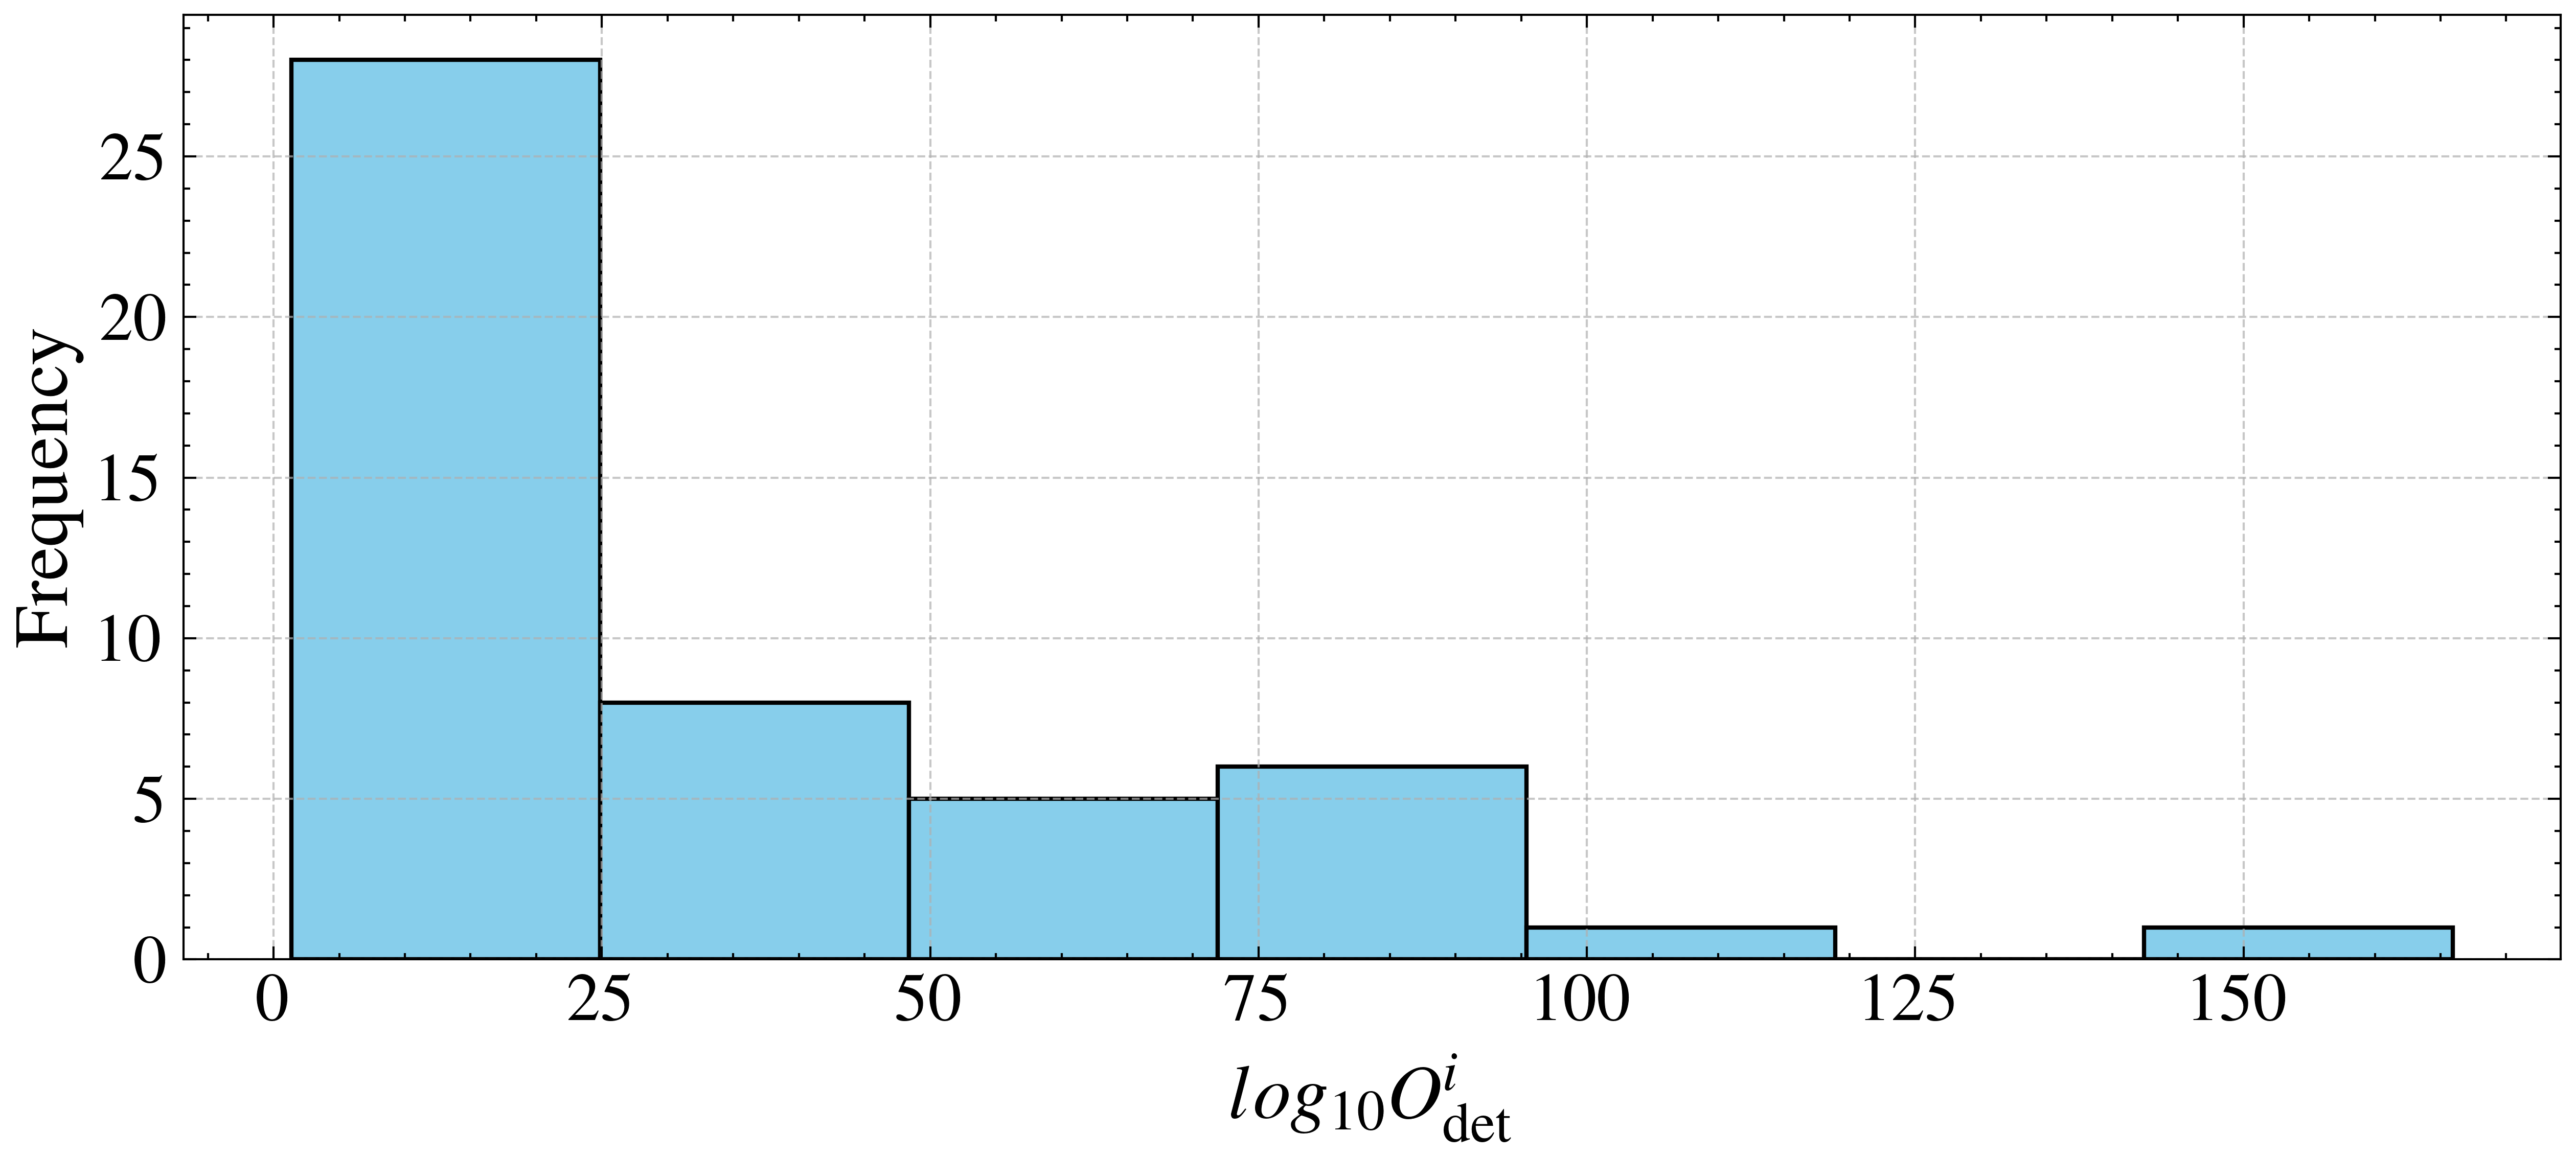

In [3]:
# making the bayes factor histogram plot
csv = 'src_pos_tidy_xyz.csv'
data = pd.read_csv(csv)
posterior_odds = data['posterior_odds'].values
# opt out the bayes_factor values if the value of chi_sq in the same row is larger than 100
chi_sq_values = data['chi_sq'].values
posterior_odds = posterior_odds[chi_sq_values <= 10] # type: ignore
print(f"Number of posterior odds values with chi_sq <= 10: {len(posterior_odds)}")
# posterior_odds are in ln base, change to log 10 base
posterior_odds = posterior_odds * np.log10(np.e)
#print(posterior_odds)

# getting the bin number using Freedman-Diaconis rule
def freedman_diaconis(data):
    q75, q25 = np.percentile(data, [75 ,25])
    iqr = q75 - q25
    bin_width = 2 * iqr * len(data) ** (-1/3)
    bin_count = int((data.max() - data.min()) / bin_width)
    return bin_count


plt.figure(figsize=(10, 4))
plt.hist(posterior_odds, color='skyblue', edgecolor='black', bins=freedman_diaconis(posterior_odds))
# add grid lines in x and y direction
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# set the font size of the ticks
plt.tick_params(axis='both', which='major', labelsize=16)
plt.ylabel('Frequency', fontsize=18)
plt.xlabel(r'$log_{10} O^i_\text{det}$', fontsize=18)

#plt.savefig('Report images sem2/new/posterior_odds_histogram_xyz.pdf', bbox_inches='tight')


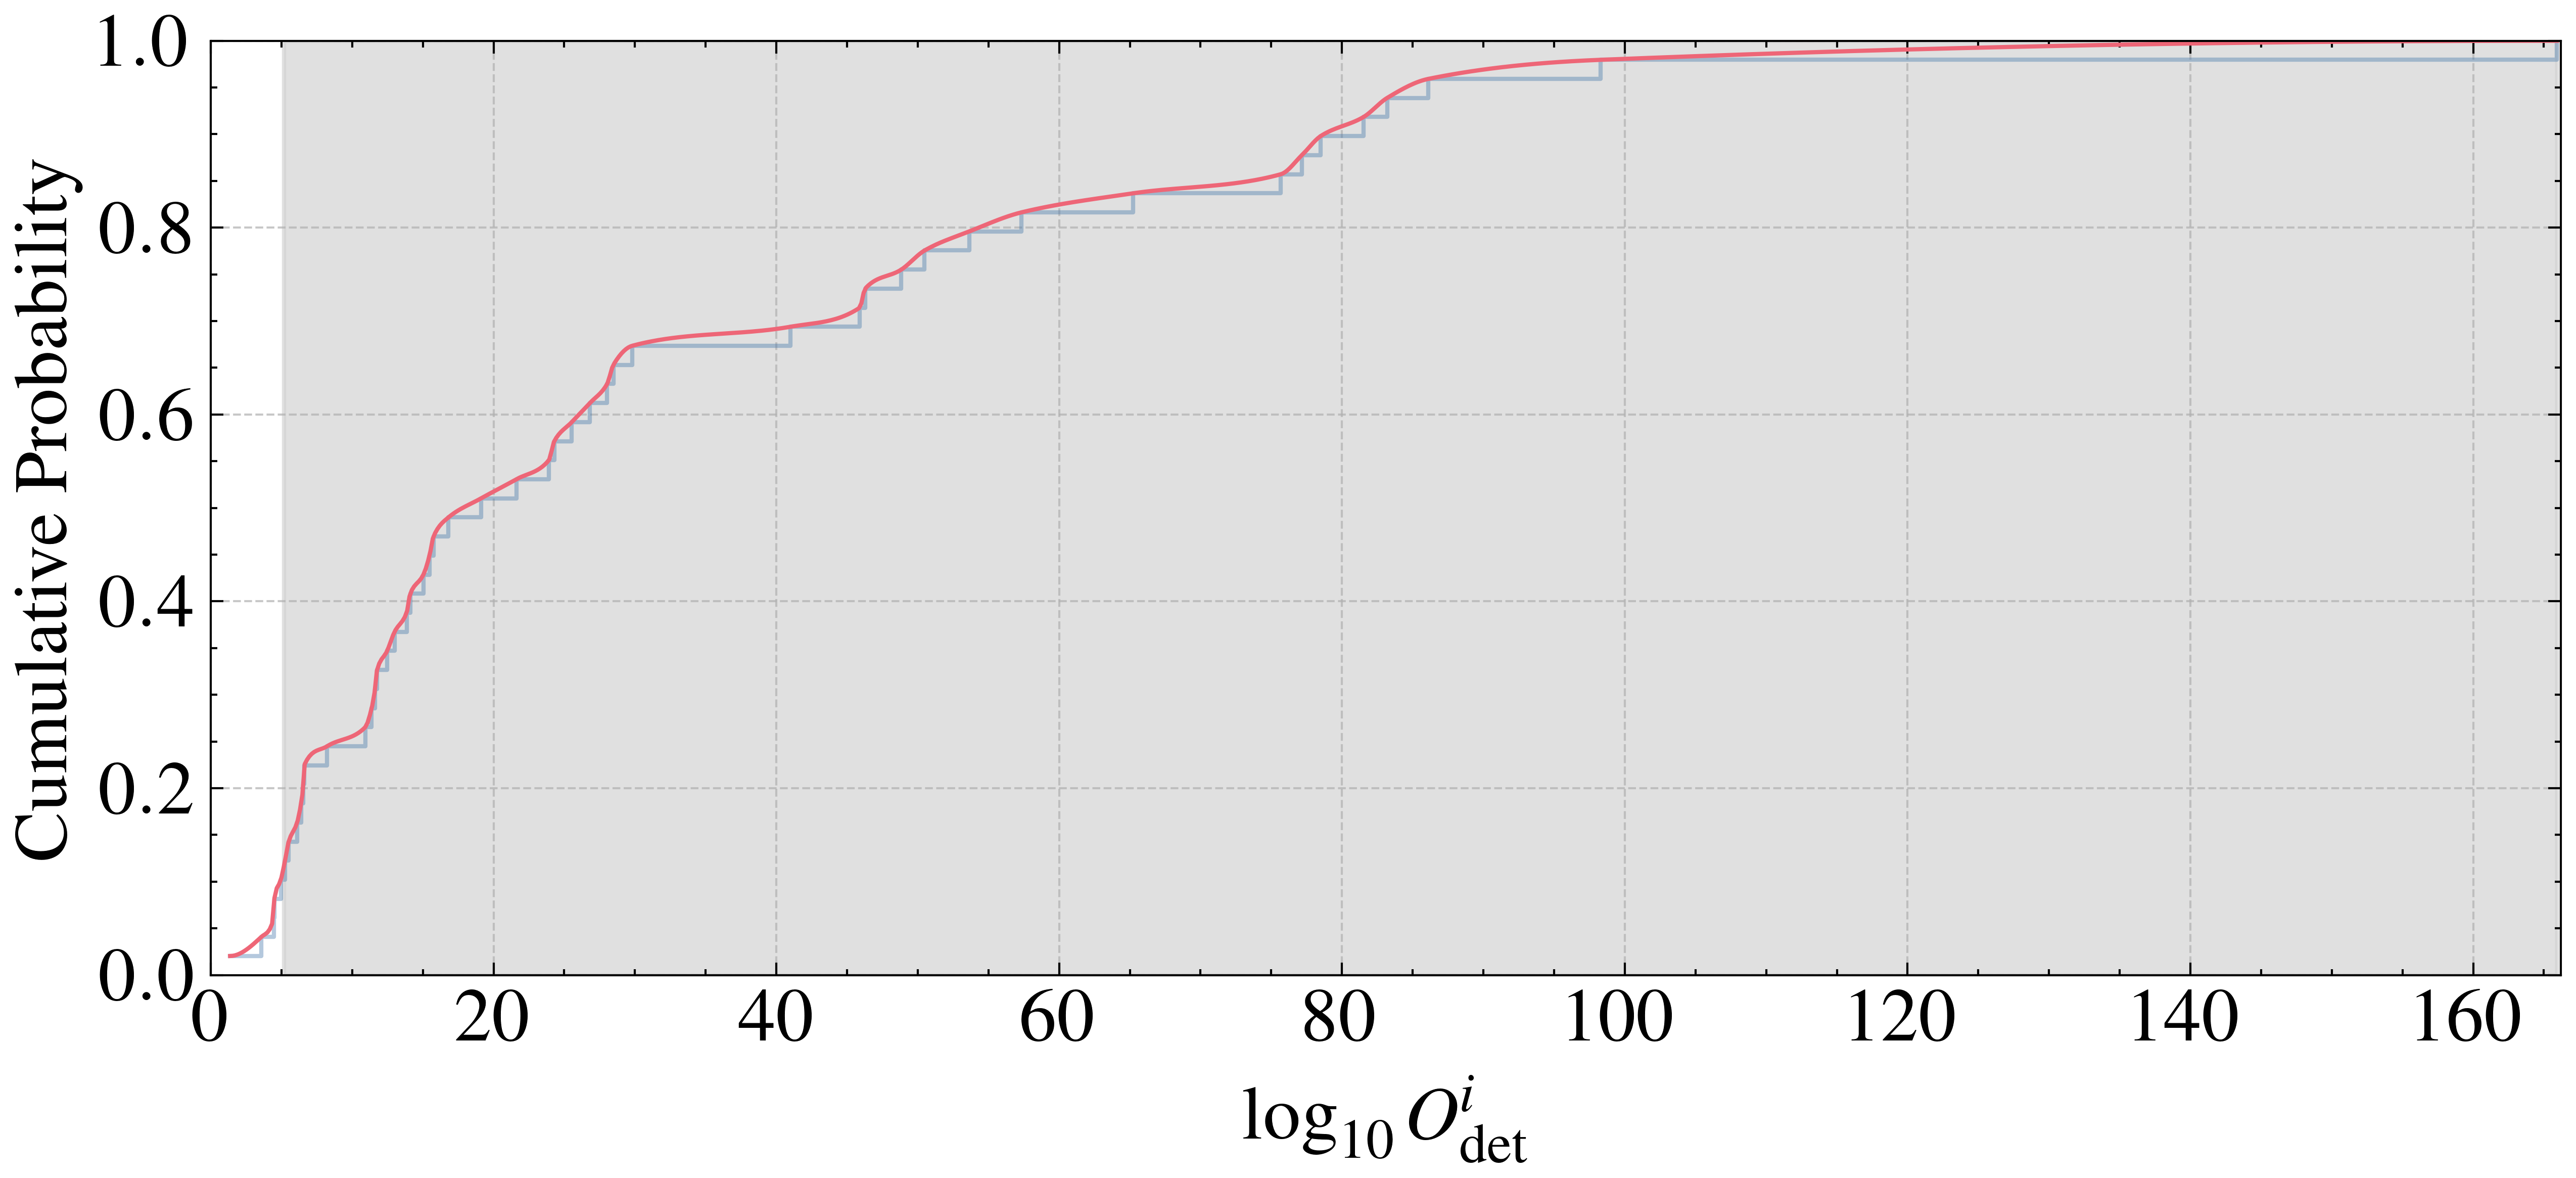

In [4]:
from scipy.interpolate import PchipInterpolator

x = np.asarray(posterior_odds, dtype=float)
x = x[np.isfinite(x)]
xs = np.sort(x)
n = xs.size

# ECDF (step)
ecdf = np.arange(1, n + 1) / n

# PCHIP needs strictly increasing x -> compress duplicates:
xu = np.unique(xs)
yu = np.searchsorted(xs, xu, side="right") / n  # ECDF value at last duplicate

pchip = PchipInterpolator(xu, yu)  # monotone, smooth
grid = np.linspace(xu[0], xu[-1], 1000)
ecdf_smooth = np.clip(pchip(grid), 0, 1)

plt.figure(figsize=(10, 4))
plt.step(xs, ecdf, where="post", alpha=0.4)
plt.plot(grid, ecdf_smooth)
# fill the whole space after x > 5 with a grey color
plt.fill_between(grid, 0, 1.0, where=grid > 5, color='lightgray', alpha=0.7, interpolate=True)
plt.grid(axis="both", linestyle="--", alpha=0.7)
plt.ylabel("Cumulative Probability", fontsize=18)
plt.xlabel(r"$\log_{10}O^i_\text{det}$", fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xticks(np.arange(0, 180, 20)) if csv == 'src_pos_tidy_xyz.csv' else plt.xticks(np.arange(0, 1300, 100))
plt.xlim(0, 166.2) if csv == 'src_pos_tidy_xyz.csv' else plt.xlim(0, 1201)
plt.ylim(0, 1.00)
plt.savefig('Report images sem2/new/posterior_odds_cdf_xyz.pdf', bbox_inches='tight') if csv == 'src_pos_tidy_xyz.csv' else plt.savefig('Report images sem2/new/posterior_odds_cdf_xy.pdf', bbox_inches='tight')

Number of filtered npz files: 49
Mean uncertainty in x: 0.32 arcsec
Mean uncertainty in y: 0.33 arcsec
Mean uncertainty in z: 0.26
Minimum uncertainty in x: 0.05 arcsec
Minimum uncertainty in y: 0.08 arcsec
Minimum uncertainty in z: 0.05
Maximum uncertainty in x: 0.99 arcsec
Maximum uncertainty in y: 1.17 arcsec
Maximum uncertainty in z: 0.62


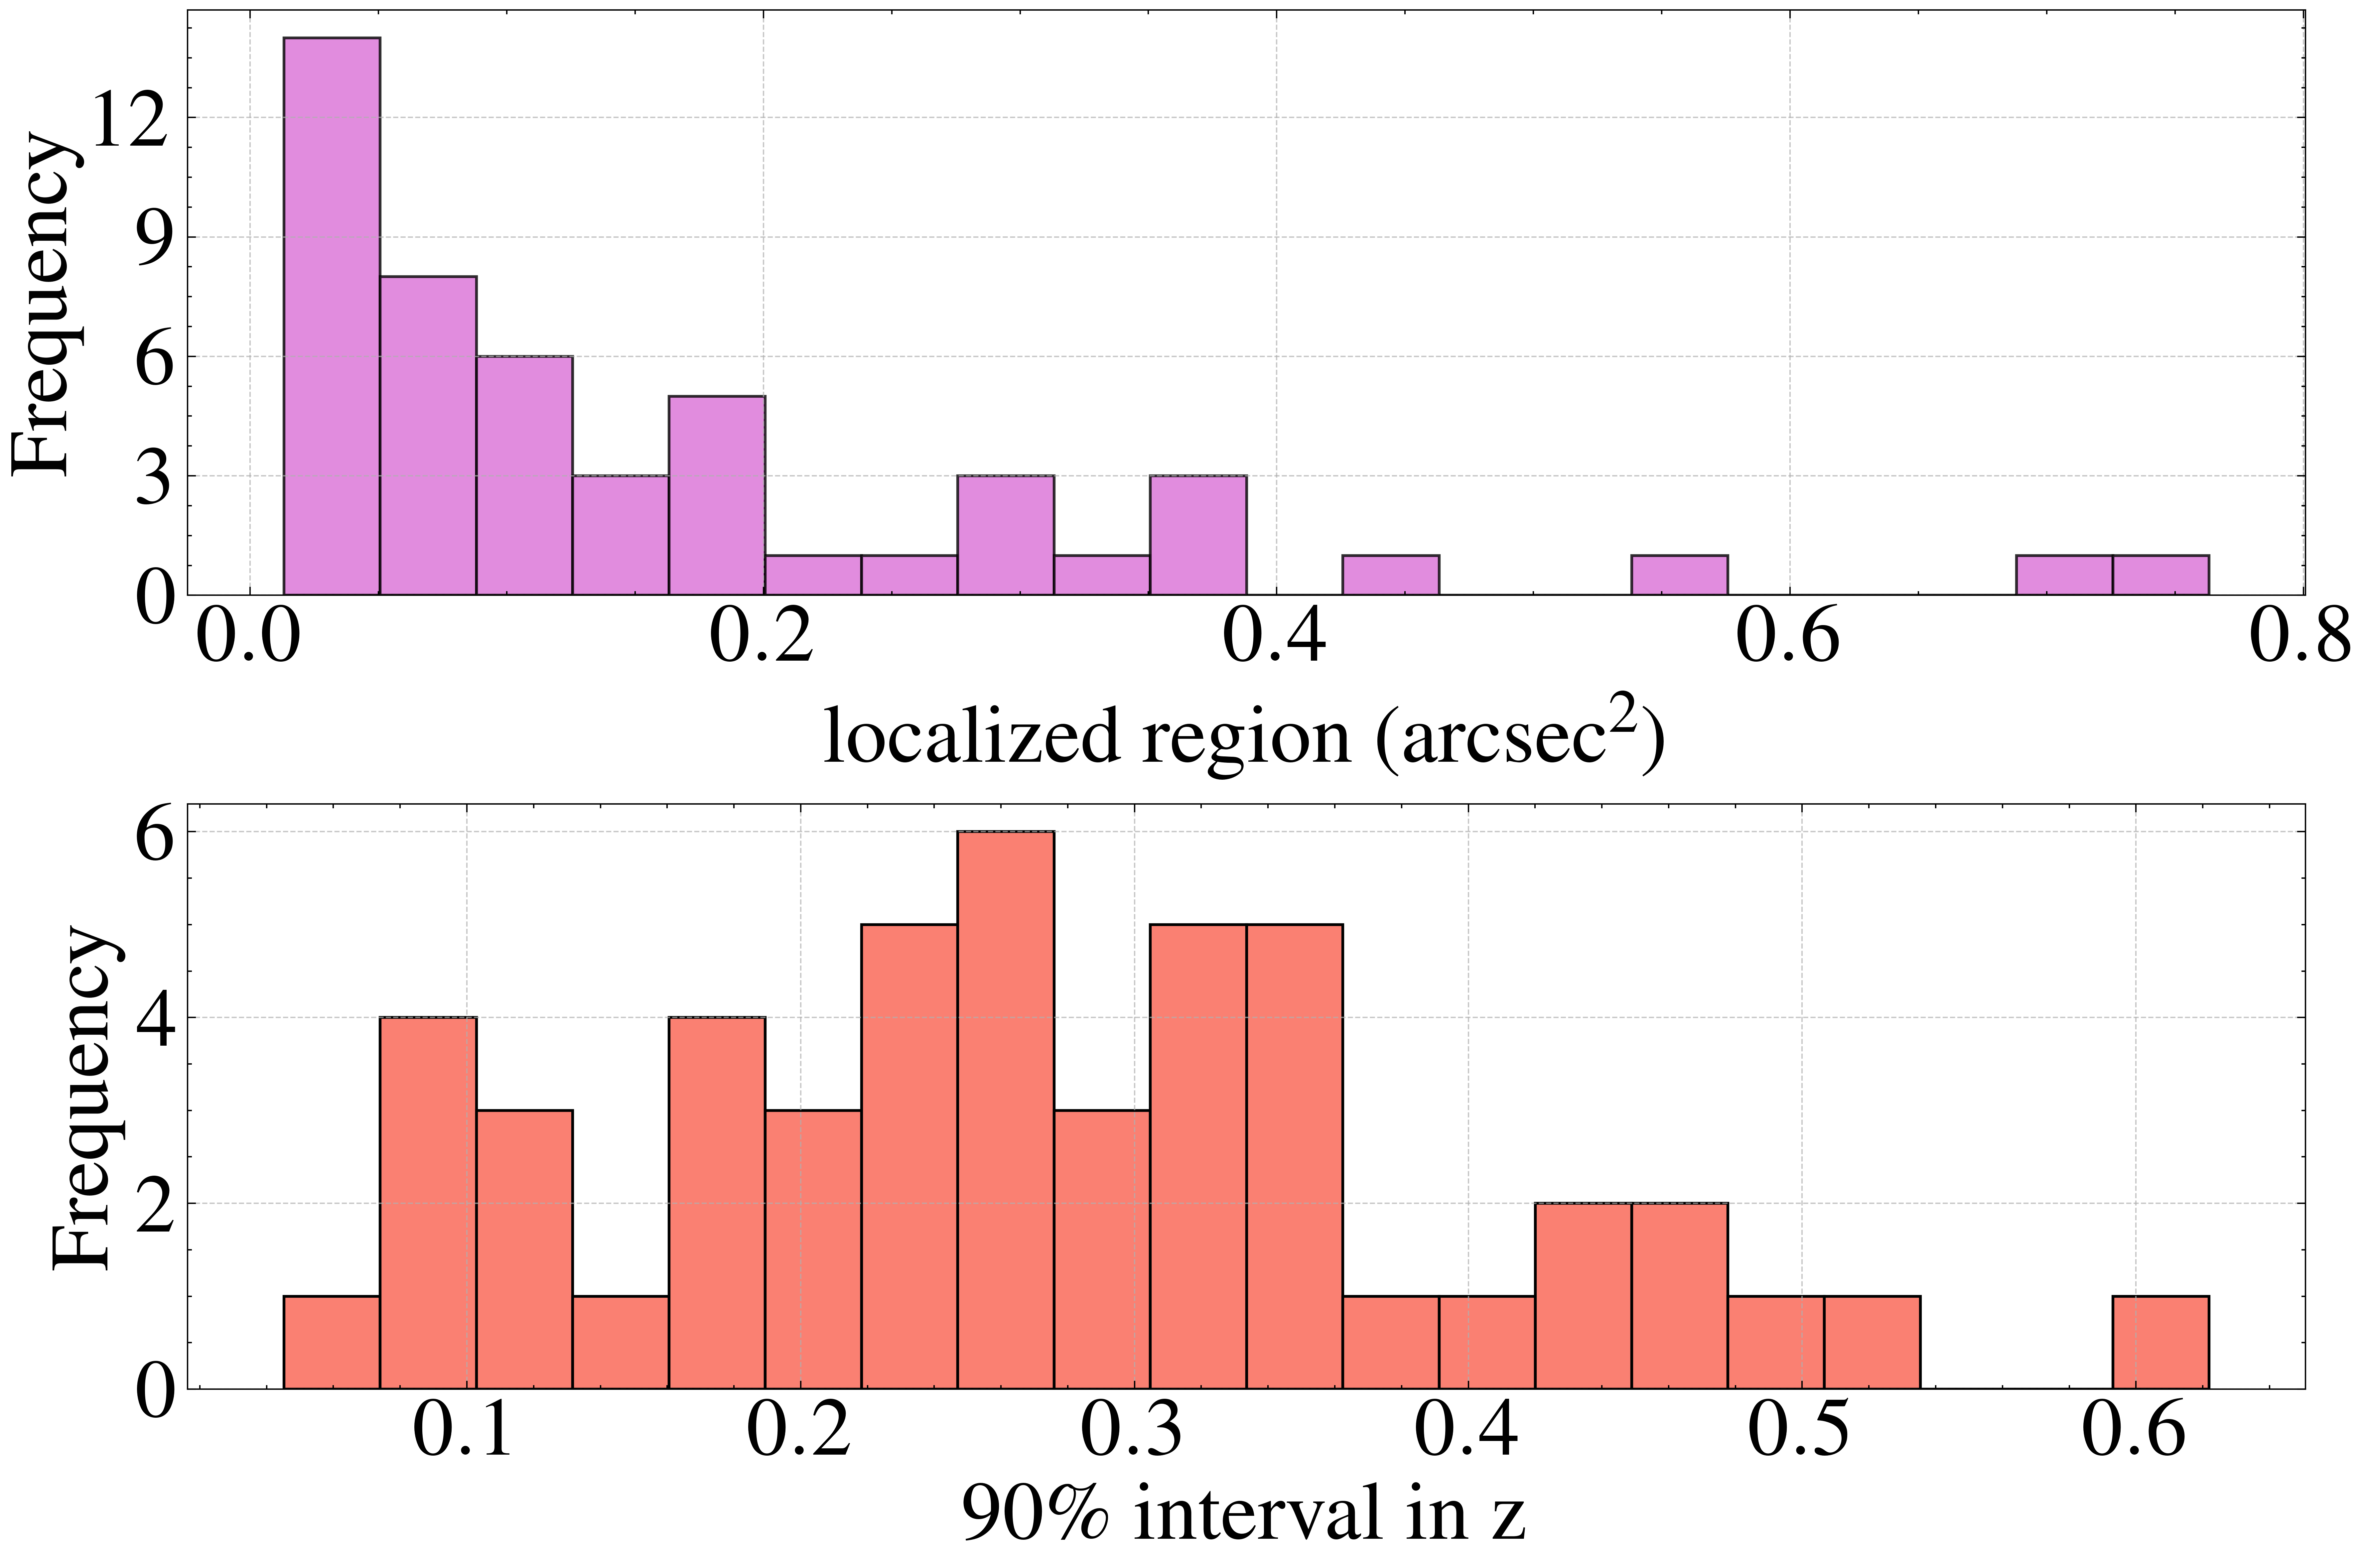

In [5]:
import glob
from matplotlib.ticker import MaxNLocator
# make the plot of uncertainty in histogram
# get all the npz file from the folder
OUT_DIR = '/home/dices/Research/GWlensing_Brian/outputs/fix_z_imgs' if csv == 'src_pos_tidy_xy.csv' else '/home/dices/Research/GWlensing_Brian/outputs/with_z_imgs' if csv == 'src_pos_tidy_xyz.csv' else '/home/dices/Research/GWlensing_Brian/outputs/with_z_imgs'
npz_files = glob.glob(os.path.join(OUT_DIR, 'row*','test_tidy_row*', '*.npz'))
# drop the npz files if its folder contains more than 1 .npz file, or the corresponding chi sq value is larger than 20 in the corresponding src_pos_tidy_xyz.csv file
filtered_npz_files = []
accepted_rows = []
localized_data = pd.read_csv(csv)
for npz_file in npz_files:
    # extract the row number from the npz file path
    row_number = int(pathlib.Path(npz_file).parts[-3][3:])  # 'rowX' -> X
    # get the chi sq value from the localized_data dataframe
    chi_sq_value = localized_data.loc[row_number, 'chi_sq']
    # count the number of npz files in the same folder
    folder_path = os.path.dirname(npz_file)
    num_npz_in_folder = len(glob.glob(os.path.join(folder_path, '*.npz')))
    if chi_sq_value <= 10 and num_npz_in_folder == 1: # type: ignore
        filtered_npz_files.append(npz_file)
        accepted_rows.append(row_number)

print(f"Number of filtered npz files: {len(filtered_npz_files)}")


all_uncertainties = []

# get the uncertainty from each npz file
for npz_file in filtered_npz_files:
    mcmc_data = np.load(npz_file)
    flat_chain = mcmc_data['flat_chain']
    # calculate the 90% credible interval as the uncertainty for the parameters in the npz file
    uncertainty = np.percentile(flat_chain, 95, axis=0) - np.percentile(flat_chain, 5, axis=0)
    all_uncertainties.extend(uncertainty)
# rearrange the uncertainties into separate lists for x, y, and z when available
n_params = 2 if csv == 'src_pos_tidy_xy.csv' else 3
uncertainties = np.array(all_uncertainties).reshape(-1, n_params)
uncertainties_x = uncertainties[:, 0]
uncertainties_y = uncertainties[:, 1]
if csv != 'src_pos_tidy_xy.csv':
    uncertainties_z = uncertainties[:, 2]
uncertainties_area = uncertainties_x * uncertainties_y
#print(uncertainties_x)
# plot the histogram of the uncertainties
# print the mean and minimum and maximum of the uncertainties for x, y, z
print(f"Mean uncertainty in x: {np.median(uncertainties_x):.2f} arcsec")
print(f"Mean uncertainty in y: {np.median(uncertainties_y):.2f} arcsec")
if csv != 'src_pos_tidy_xy.csv':
    print(f"Mean uncertainty in z: {np.median(uncertainties_z):.2f}")
print(f"Minimum uncertainty in x: {np.min(uncertainties_x):.2f} arcsec")
print(f"Minimum uncertainty in y: {np.min(uncertainties_y):.2f} arcsec")
if csv != 'src_pos_tidy_xy.csv':
    print(f"Minimum uncertainty in z: {np.min(uncertainties_z):.2f}")
print(f"Maximum uncertainty in x: {np.max(uncertainties_x):.2f} arcsec")
print(f"Maximum uncertainty in y: {np.max(uncertainties_y):.2f} arcsec")
if csv != 'src_pos_tidy_xy.csv':
    print(f"Maximum uncertainty in z: {np.max(uncertainties_z):.2f}")
if csv == 'src_pos_tidy_xy.csv':
    fig, axs = plt.subplots(1, 1, figsize=(12, 4), tight_layout=True)
    area_ax = axs
else:
    fig, axs = plt.subplots(2, 1, figsize=(12, 8), tight_layout=True)
    area_ax, z_ax = axs

# Plot for x and y uncertainties combined
# Determine common bins for x and y uncertainties to ensure same bin widths
# min_val = min(uncertainties_x.min(), uncertainties_y.min())
# max_val = max(uncertainties_x.max(), uncertainties_y.max())
min_val = uncertainties_area.min()
max_val = uncertainties_area.max()
bins = np.linspace(min_val, max_val, 21)  # 20 bins

# axs[0].hist(uncertainties_x, bins=bins, color='blue', edgecolor='black', alpha=0.7, label=r'$\beta_x$')
# axs[0].hist(uncertainties_y, bins=bins, color='lightgreen', edgecolor='black', alpha=0.7, label=r'$\beta_y$')
area_ax.hist(uncertainties_area, bins=bins, color='orchid', edgecolor='black', alpha=0.8, label=r'$\beta_x \times \beta_y$')
area_ax.set_xlabel(r'localized region (arcsec$^2$)', fontsize=30)
area_ax.set_ylabel('Frequency', fontsize=30)
area_ax.grid(axis='both', linestyle='--', alpha=0.7)
area_ax.tick_params(axis='both', which='major', labelsize=30)
area_ax.yaxis.set_major_locator(MaxNLocator(nbins=6,integer=True))

# Plot for z uncertainty
if csv != 'src_pos_tidy_xy.csv':
    z_ax.hist(uncertainties_z, bins=20, color='salmon', edgecolor='black')
    z_ax.set_xlabel(r'90\% interval in z', fontsize=30)
    z_ax.set_ylabel('Frequency', fontsize=30)
    z_ax.grid(axis='both', linestyle='--', alpha=0.7)
    z_ax.tick_params(axis='both', which='major', labelsize=30)
    z_ax.yaxis.set_major_locator(MaxNLocator(nbins=6,integer=True))

plt.savefig('Report images sem2/new/90_interval_area_xyz.pdf', bbox_inches='tight') if csv == 'src_pos_tidy_xyz.csv' else plt.savefig('Report images sem2/new/90_interval_area_xy.pdf', bbox_inches='tight')


In [104]:
# get the correlation map between the relative time delays, largest relative magnifications, and the bayes factor of the 60 events
# get the bayes factor from the selected CSV file
OUT_DIR = '/home/dices/Research/GWlensing_Brian/outputs/fix_z_imgs' if csv == 'src_pos_tidy_xy.csv' else '/home/dices/Research/GWlensing_Brian/outputs/with_z_imgs'
data = pd.read_csv(csv)
posterior_odds = data['posterior_odds'].values
localized_index = data['localized_index'].values
localized_x = data['localized_x'].values
localized_y = data['localized_y'].values
localized_z = data['localized_z'].values
# For fixed-z XY runs, use the original source redshift. Otherwise use the localized z.
original_z = data['z'].values
source_z = original_z if csv == 'src_pos_tidy_xy.csv' else localized_z
filtered_original_z = []
filtered_source_z = []
# opt out the posterior_odds values if the value of chi_sq in the same row is too large or the number of .npz files in the corresponding folder is more than 1
chi_sq_cut = 10
chi_sq_values = data['chi_sq'].values
filtered_posterior_odds = []
filtered_localized_index = []
filtered_localized_x = []
filtered_localized_y = []
filtered_localized_z = []
for i in range(len(posterior_odds)):
    row_number = i
    chi_sq_value = chi_sq_values[i]
    folder_path = os.path.join(OUT_DIR, f'row{row_number}', f'test_tidy_row{row_number}')
    num_npz_in_folder = len(glob.glob(os.path.join(folder_path, '*.npz')))
    if chi_sq_value <= chi_sq_cut and num_npz_in_folder == 1:
        filtered_posterior_odds.append(posterior_odds[i])
        filtered_localized_index.append(localized_index[i])
        filtered_localized_x.append(localized_x[i])
        filtered_localized_y.append(localized_y[i])
        filtered_localized_z.append(localized_z[i])

        filtered_original_z.append(original_z[i])
        filtered_source_z.append(source_z[i])
print(f"Number of filtered posterior odds: {len(filtered_posterior_odds)}")

# get the image positions, time delays, and magnifications from each x,y,z pair with the index
image_positions = []
time_delays = []
magnifications = []
for i in range(len(filtered_localized_x)):
    x = filtered_localized_x[i]
    y = filtered_localized_y[i]
    z = filtered_source_z[i]
    index = filtered_localized_index[i]
    # use the clusterlensing class to calculate the image positions, time delays, and magnifications
    test_params = {"x_src" : x, "y_src": y, "z_s": z, "H0": 70}
    test_cluster = int(index)
    output = cluster_system.calculate_imgs_delays_magns(
        test_params, test_cluster
    )
    #print(test_params)
    #print(output['image_positions'])
    image_positions.append(output['image_positions'])
    largest_time_delay = np.max(output['time_delays']) - np.min(output['time_delays'])
    largest_magnification = np.max(np.abs(output['magnifications']))
    time_delays.append(largest_time_delay)
    magnifications.append(largest_magnification)
    
filtered_posterior_odds = np.array(filtered_posterior_odds) * np.log10(np.e)

Number of filtered posterior odds: 49


Number of events for cluster 0: 9
Number of events for cluster 1: 7
Number of events for cluster 2: 10
Number of events for cluster 3: 7
Number of events for cluster 4: 8
Number of events for cluster 5: 8


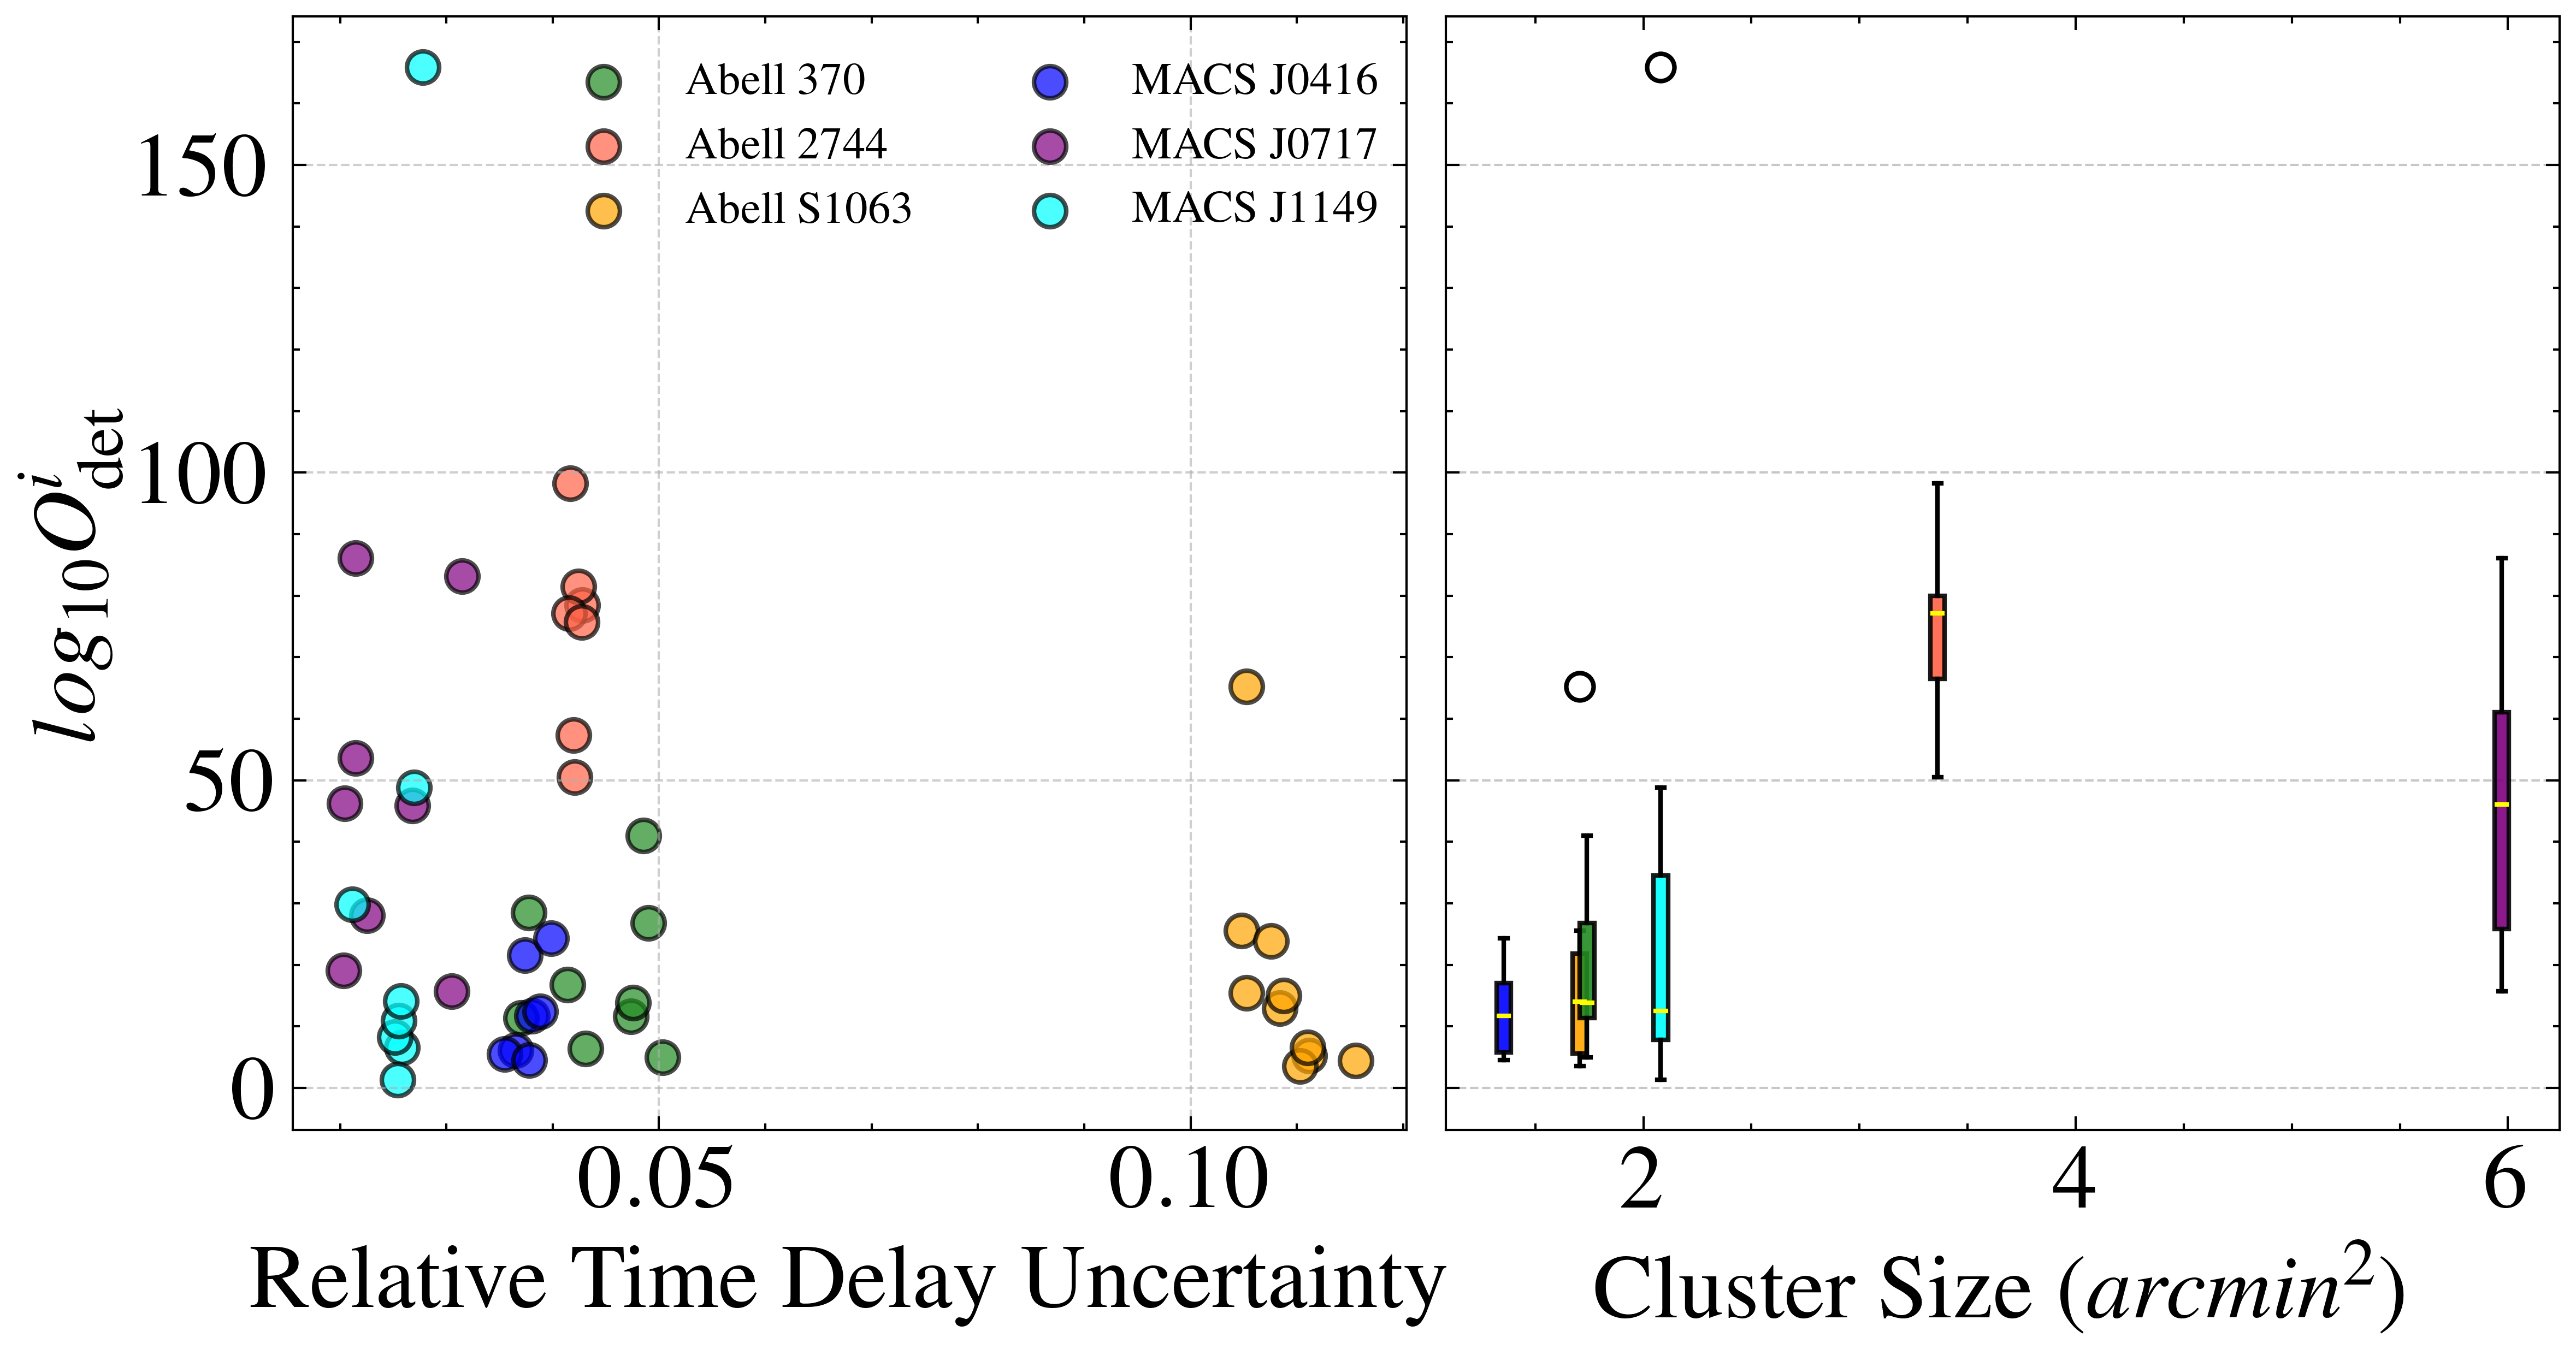

In [107]:
# plot the time delay uncertainty, cluster size, z_s vs bayes factor
# get the time delay uncertainty of each image position
time_delay_uncertainties_largest = []
time_delay_uncertainties_all = []
for i in range(len(filtered_localized_x)):
    x_img = image_positions[i][0],
    y_img = image_positions[i][1],
    index = int(filtered_localized_index[i])
    time_delay_uncertainties = cluster_system.calculate_time_delay_uncertainty(
        [x_img, y_img], index
    )
    time_delay_uncertainties_largest.append(np.max(time_delay_uncertainties))
    time_delay_uncertainties_all.append(time_delay_uncertainties)
# plot the time delay uncertainty vs bayes factor
fig, axs = plt.subplots(1, 2, figsize=(8, 4.5), tight_layout=True, sharey=True)

# Define a colormap and labels for the clusters from cell 9
colors = ['forestgreen', 'tomato', 'orange', 'blue', 'purple', 'cyan']
cluster_labels = {
    0: 'Abell 370', 1: 'Abell 2744', 2: 'Abell S1063',
    3: 'MACS J0416', 4: 'MACS J0717', 5: 'MACS J1149'
}

# Plot for time delay uncertainty vs bayes factor
for i in range(6):
    mask = np.array(filtered_localized_index) == i
    if np.any(mask):
        print(f"Number of events for cluster {i}: {np.sum(mask)}")
        axs[0].scatter(np.array(time_delay_uncertainties_largest)[mask], np.array(filtered_posterior_odds)[mask], 
                       color=colors[i], s=50, marker='o', edgecolor='k', alpha=0.7, label=cluster_labels[i])
axs[0].set_xlabel(r'Relative Time Delay Uncertainty', fontsize=20)
axs[0].set_ylabel(r'$log_{10} O^i_\text{det}$', fontsize=20)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].tick_params(axis='both', which='major', labelsize=20)
# get the cluster size from the lensing data class
data_to_plot = [[] for _ in range(6)]
for index, bf in zip(filtered_localized_index, filtered_posterior_odds):
    data_to_plot[int(index)].append(bf)

data_by_cluster = [[] for _ in range(6)]
for index, bf in zip(filtered_localized_index, filtered_posterior_odds):
    data_by_cluster[int(index)].append(bf)

# Cluster sizes in the same order as the clusters (arcmin^2)
cluster_sizes = np.array([1.7392, 3.3609, 1.7059, 1.3541, 5.9715, 2.0806], dtype=float)

# Sort by cluster size
sorted_indices = np.argsort(cluster_sizes)
sorted_cluster_sizes = cluster_sizes[sorted_indices]
sorted_data_to_plot = [data_by_cluster[i] for i in sorted_indices]

# Set a reasonable box width based on spacing in cluster sizes
unique_sizes = np.unique(sorted_cluster_sizes)
if len(unique_sizes) > 1:
    spacing = np.min(np.diff(unique_sizes))
    box_width = 2 * spacing
else:
    box_width = 0.1 * unique_sizes[0]

# Create a box plot at x = cluster sizes (like the sample code)
box = axs[1].boxplot(
    sorted_data_to_plot,
    positions=sorted_cluster_sizes,
    widths=box_width,
    patch_artist=True,
    manage_ticks=False
)

# Color the boxes – same style as the sample code, but mapped from your cluster colors
box_colors = [colors[i] for i in sorted_indices]
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.9)

# Style medians to match the sample
for median in box['medians']:
    median.set_color('yellow')

axs[1].grid(axis='y', linestyle='--', alpha=0.7)
axs[1].set_xlabel(r'Cluster Size ($arcmin^2$)', fontsize=20)
axs[1].tick_params(axis='both', which='major', labelsize=20)

# plot the source redshift vs bayes factor
# for i in range(6):
#     mask = np.array(filtered_localized_index) == i
#     if np.any(mask):
#         axs[2].scatter(np.array(filtered_localized_z)[mask], np.array(filtered_posterior_odds)[mask], 
#                        color=colors[i], s=50, marker='o', edgecolor='k', alpha=0.7)
# axs[2].set_xlabel('Source Redshift z_s', fontsize=20)
# axs[2].set_ylabel(r'$log_{10} O^i_\text{det}$', fontsize=20)
# axs[2].grid(True, linestyle='--', alpha=0.6)
# axs[2].tick_params(axis='both', which='major', labelsize=20)

fig.legend(handles=axs[0].get_legend_handles_labels()[0], labels=cluster_labels.values(),  bbox_to_anchor=(0.55, 0.92), ncol=2, fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Report images sem2/new/O_vs_dt_size_z_xyz.pdf', bbox_inches='tight')

Number of events for cluster 0: 9
Number of events for cluster 1: 8
Number of events for cluster 2: 10
Number of events for cluster 3: 7
Number of events for cluster 4: 9
Number of events for cluster 5: 7


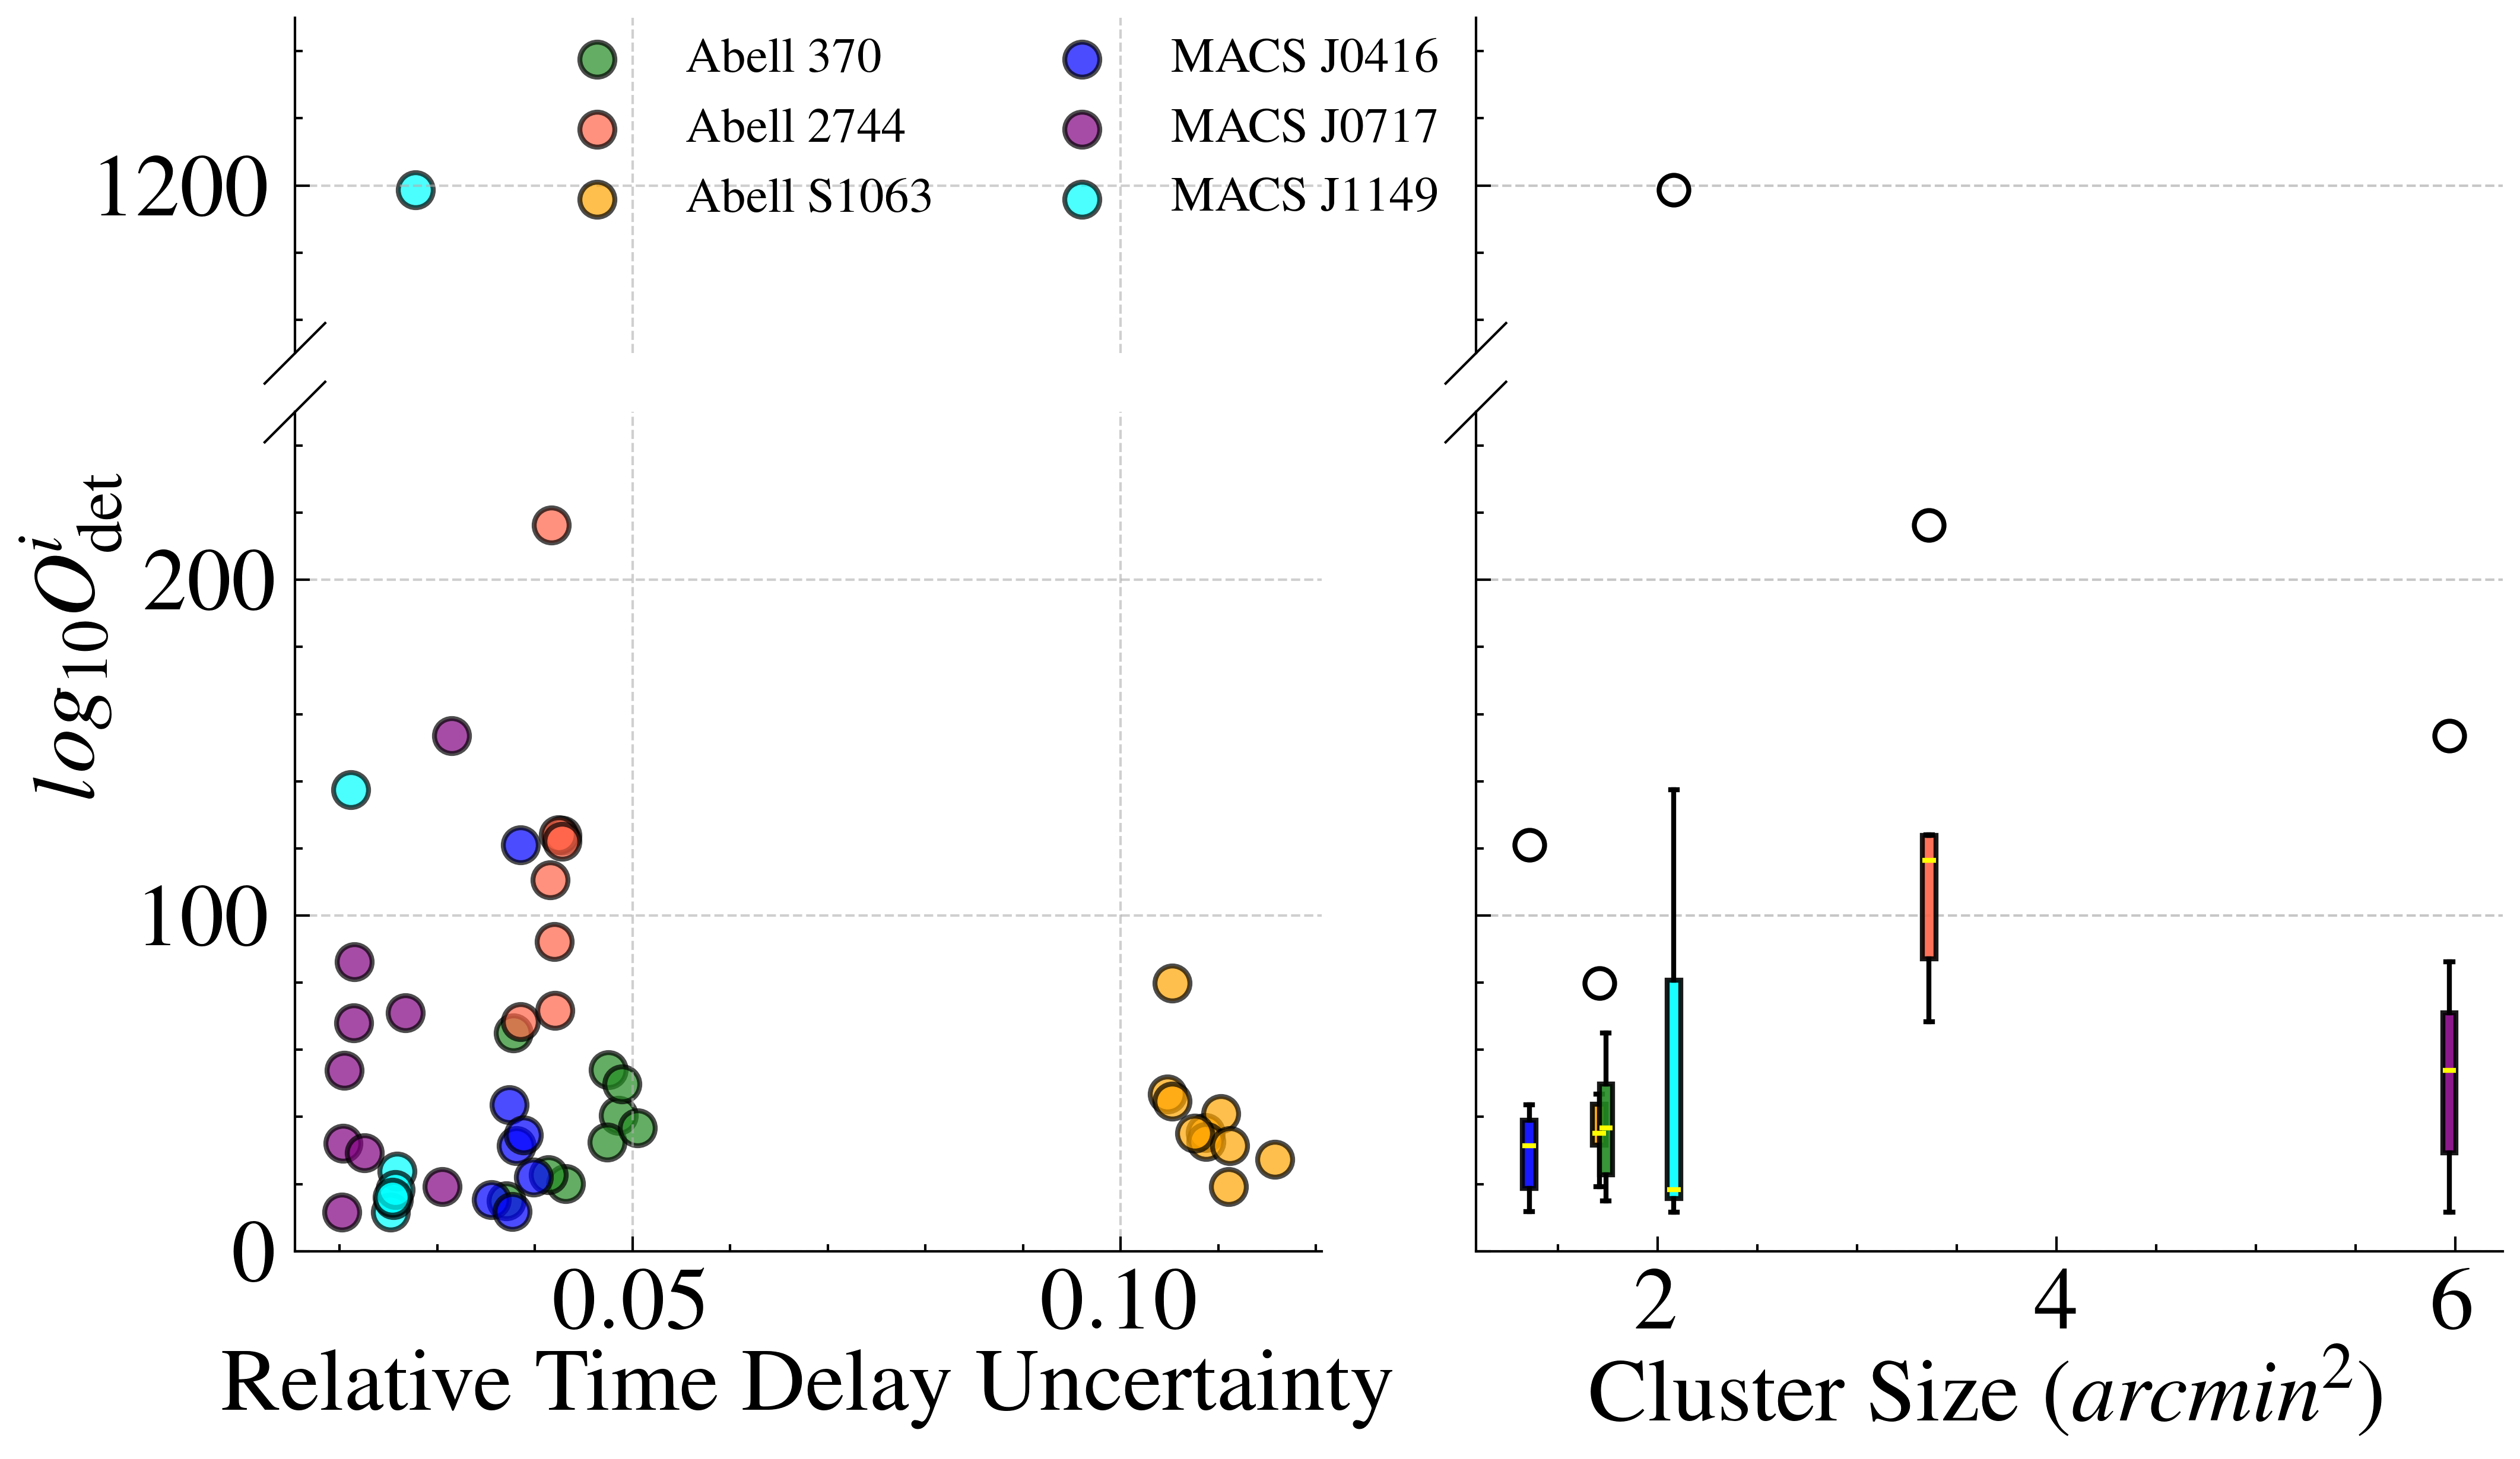

In [100]:
# for xy sampling

from brokenaxes import brokenaxes
import matplotlib.gridspec as gridspec

# plot the time delay uncertainty, cluster size, z_s vs bayes factor

time_delay_uncertainties_largest = []
time_delay_uncertainties_all = []

# Calculate uncertainties for all points 
for i in range(len(filtered_localized_x)):
    x_img = image_positions[i][0]
    y_img = image_positions[i][1]
    index = int(filtered_localized_index[i])
    time_delay_uncertainties = cluster_system.calculate_time_delay_uncertainty(
        [x_img, y_img], index
    )
    time_delay_uncertainties_largest.append(np.max(time_delay_uncertainties))
    time_delay_uncertainties_all.append(time_delay_uncertainties)

# Convert lists to numpy arrays
time_delay_uncertainties_largest = np.array(time_delay_uncertainties_largest)
filtered_posterior_odds = np.array(filtered_posterior_odds)
filtered_localized_index = np.array(filtered_localized_index)


# Define colors and labels
colors = ['forestgreen', 'tomato', 'orange', 'blue', 'purple', 'cyan']
cluster_labels = {
    0: 'Abell 370', 1: 'Abell 2744', 2: 'Abell S1063',
    3: 'MACS J0416', 4: 'MACS J0717', 5: 'MACS J1149'
}

# Plot setup using gridspec for shared structure with brokenaxes
fig = plt.figure(figsize=(8, 4.5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.15)

# -----------------------------------------------------------
# Left Plot: Time delay uncertainty vs Bayes factor (Broken Axis)
# -----------------------------------------------------------
bax1 = brokenaxes(ylims=((0, 250), (1150, 1250)), subplot_spec=gs[0], hspace=0.1)

for i in range(6):
    mask = filtered_localized_index == i
    if np.any(mask):
        print(f"Number of events for cluster {i}: {np.sum(mask)}")
        bax1.scatter(time_delay_uncertainties_largest[mask], filtered_posterior_odds[mask], 
                       color=colors[i], s=50, marker='o', edgecolor='k', alpha=0.7, label=cluster_labels[i])

# Modified: Added labelpad
bax1.set_xlabel(r'Relative Time Delay Uncertainty', fontsize=18, labelpad=20)
bax1.set_ylabel(r'$log_{10} O^i_\text{det}$', fontsize=18, labelpad=35)
bax1.grid(True, linestyle='--', alpha=0.6)
bax1.tick_params(axis='both', which='major', labelsize=18)


# -----------------------------------------------------------
# Right Plot: Cluster Size vs Bayes factor (Broken Axis)
# -----------------------------------------------------------

# Prepare data for box plot
data_by_cluster = [[] for _ in range(6)]
for index, bf in zip(filtered_localized_index, filtered_posterior_odds):
    data_by_cluster[int(index)].append(bf)

# Cluster sizes (arcmin^2)
cluster_sizes = np.array([1.7392, 3.3609, 1.7059, 1.3541, 5.9715, 2.0806], dtype=float)
sorted_indices = np.argsort(cluster_sizes)
sorted_cluster_sizes = cluster_sizes[sorted_indices]
sorted_data_to_plot = [data_by_cluster[i] for i in sorted_indices]

# Box width logic
unique_sizes = np.unique(sorted_cluster_sizes)
if len(unique_sizes) > 1:
    spacing = np.min(np.diff(unique_sizes))
    box_width = 2 * spacing
else:
    box_width = 0.1 * unique_sizes[0]

# Setup broken axis for the second plot, sharing the same y-limits
bax2 = brokenaxes(ylims=((0, 250), (1150, 1250)), subplot_spec=gs[1], hspace=0.1)

# Create box plot on the broken axis
# Note: brokenaxes doesn't support boxplot natively in the same way, but it passes calls through.
# However, standard boxplot might not handle the broken y-coordinates visually correctly without manual adjustment
# if the boxes span the break. Assuming points here don't span the break (given the data range).
box = bax2.boxplot(
    sorted_data_to_plot,
    positions=sorted_cluster_sizes,
    widths=box_width,
    patch_artist=True,
    manage_ticks=False
)

# Style box plot
box_colors = [colors[i] for i in sorted_indices]
# brokenaxes returns a list of dictionaries (one for each axis subplot)
if isinstance(box, list):
    for b in box:
        for patch, color in zip(b['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_edgecolor('black')
            patch.set_alpha(0.9)
        for median in b['medians']:
            median.set_color('yellow')
else:
    # Fallback for standard axes if not a list
    b = box
    for patch, color in zip(b['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_alpha(0.9)
    for median in b['medians']:
        median.set_color('yellow')

bax2.grid(axis='y', linestyle='--', alpha=0.7)
# Modified: Added labelpad
bax2.set_xlabel(r'Cluster Size ($arcmin^2$)', fontsize=18, labelpad=20)
bax2.tick_params(axis='both', which='major', labelsize=18)

# Remove y-labels on the second plot to avoid clutter since they share range
# We iterate over the axes created by brokenaxes
for ax in bax2.axs:
    ax.set_yticklabels([])
    ax.set_ylabel("")

# Legend
bax1.legend(loc='upper center', bbox_to_anchor=(0.68, 1.02), ncol=2, fontsize=10)

#plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Report images sem2/new/O_vs_dt_size_z_xy.pdf', bbox_inches='tight')


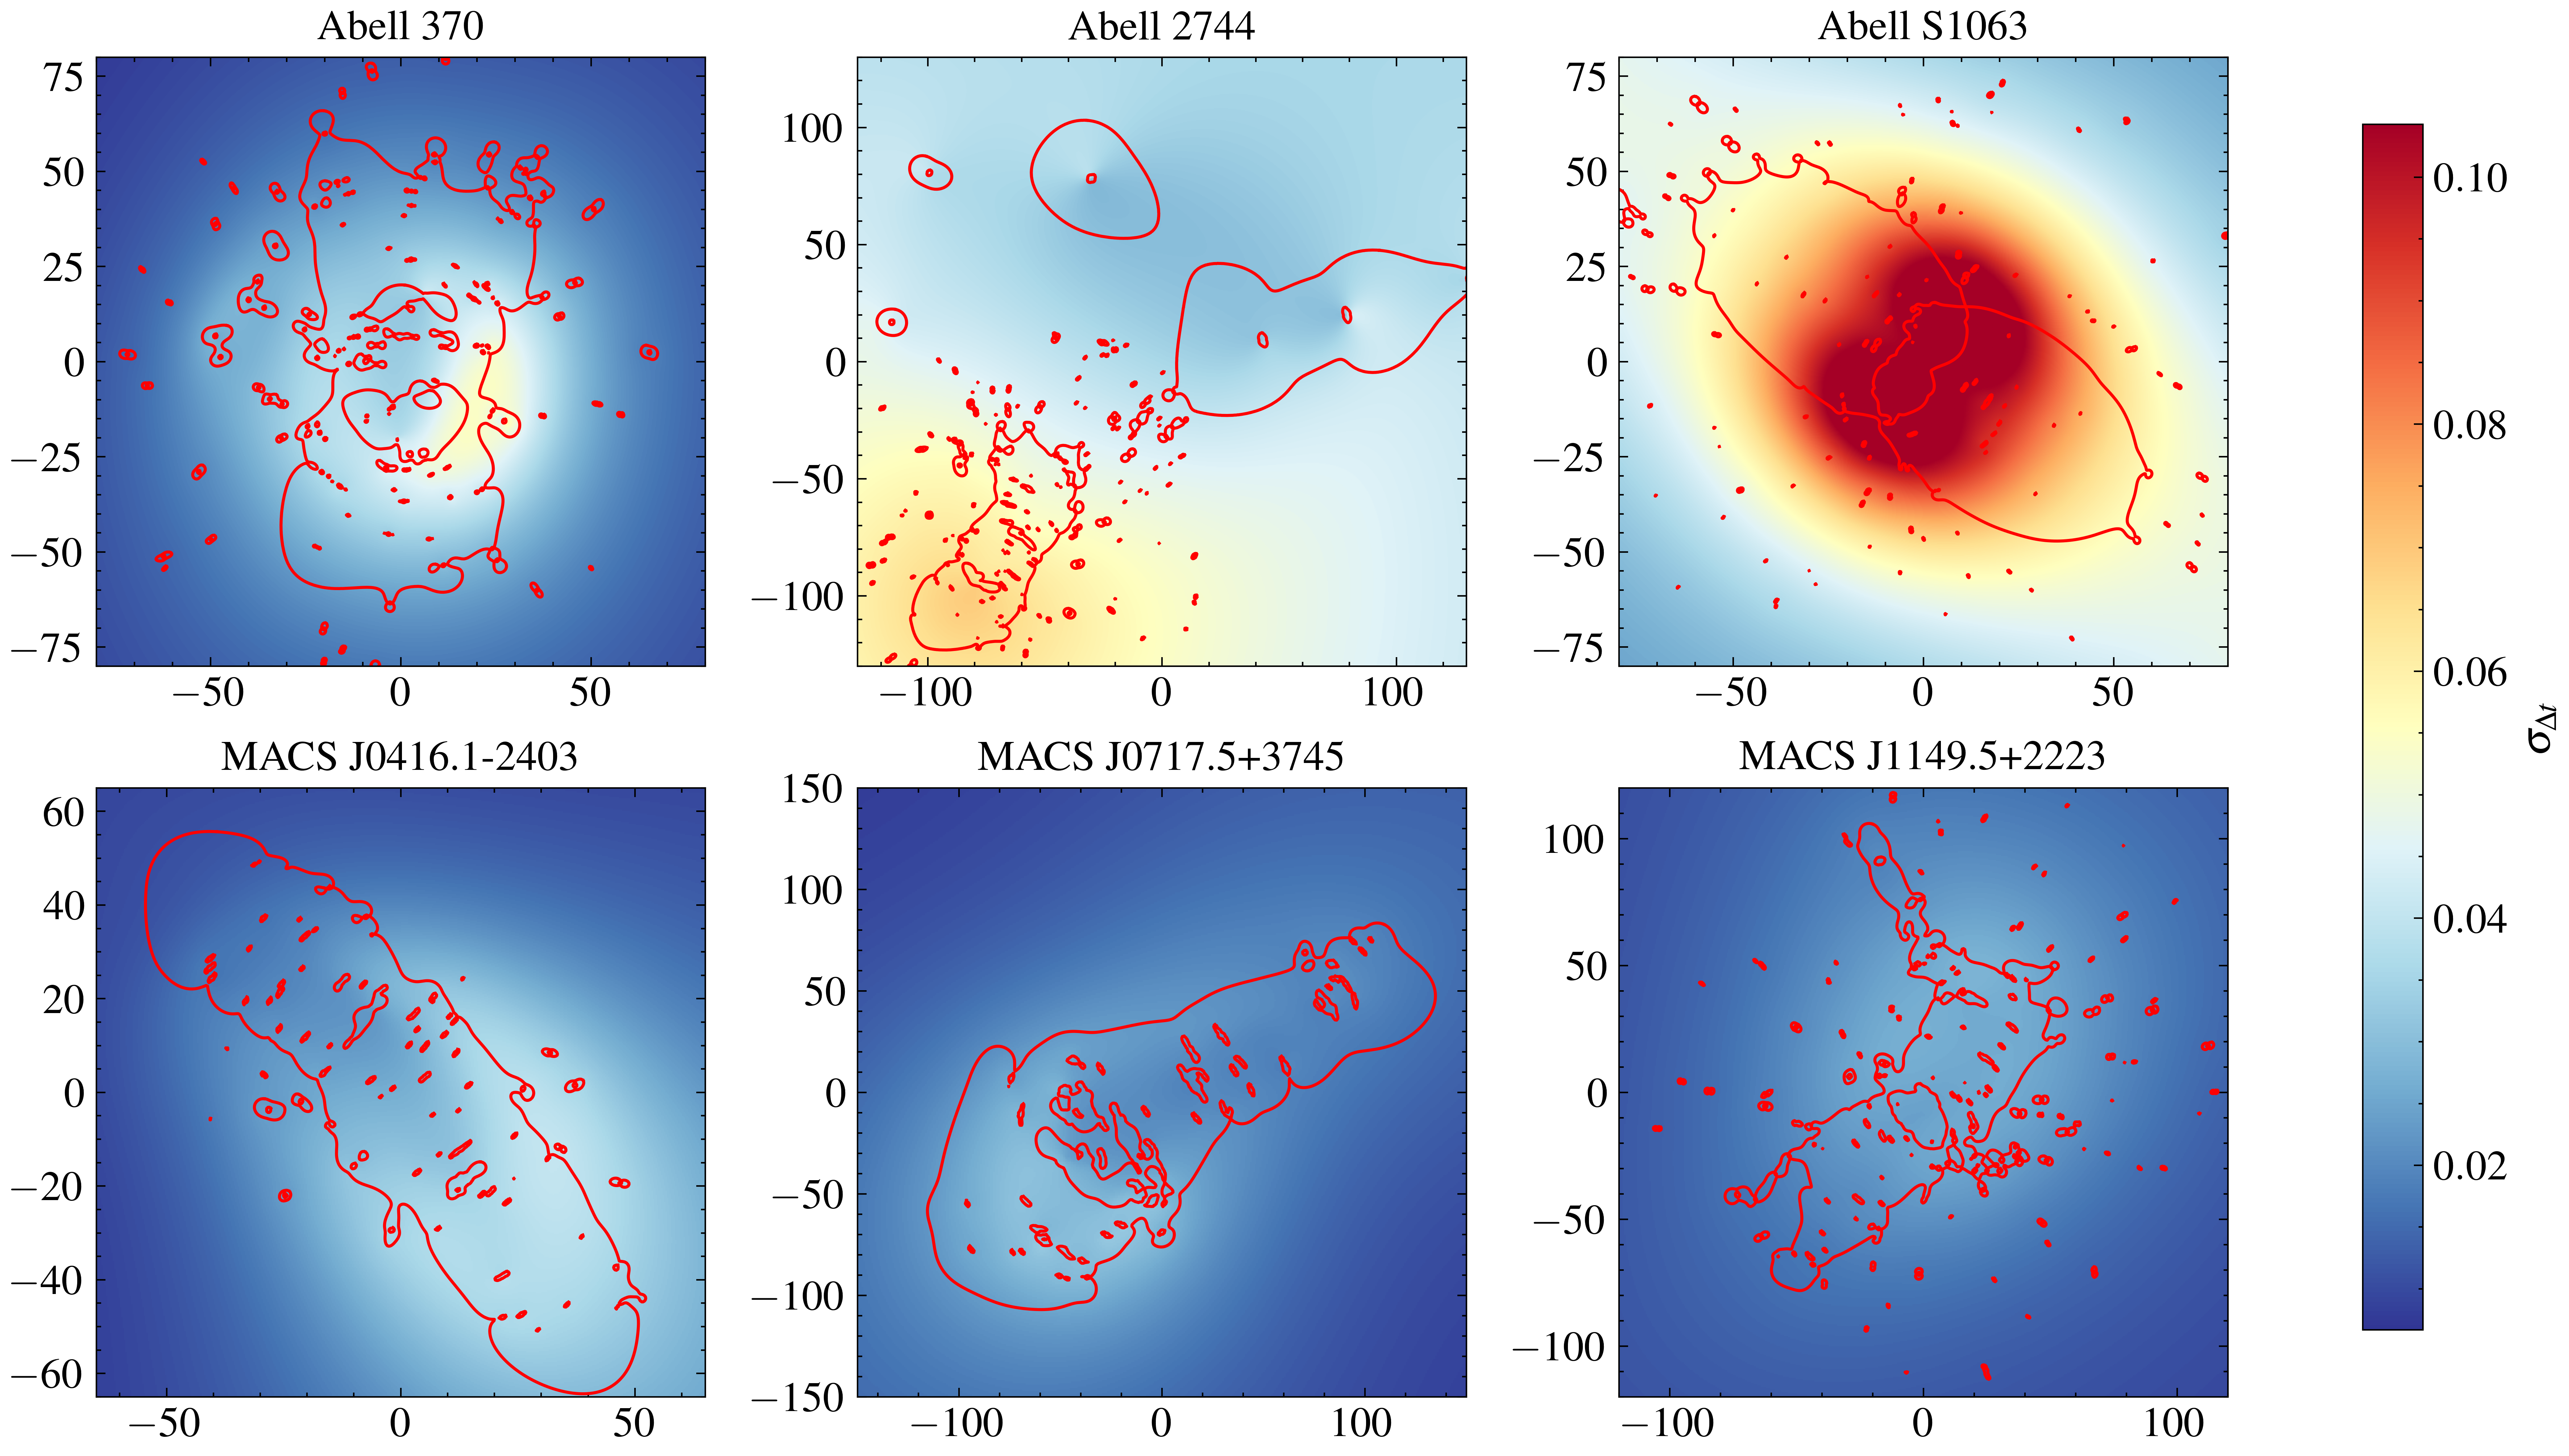

In [5]:
from matplotlib.colors import PowerNorm
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.Plots import lens_plot
# ---- cluster meta ----
Clusters = ["Abell 370", "Abell 2744", "Abell S1063",
            "MACS J0416.1-2403", "MACS J0717.5+3745", "MACS J1149.5+2223"]
clusters = ["abell370", "abell2744", "abells1063", "macs0416", "macs0717", "macs1149"]
sidepix = [800, 1200, 1000, 800, 600, 600]

# ---- load sigma_tau maps ----
sigma_tau_maps = []
for i in range(len(Clusters)):
    fits_file = f'/home/dices/Research/GWlensing_Brian/GCdata/{Clusters[i]}/cats copy/hlsp_frontier_model_{clusters[i]}_cats_v4_sigma_dt.fits'
    sigma_tau_map = fits.getdata(fits_file)
    sigma_tau_maps.append(sigma_tau_map)

# ---- compute global color scale ----
all_vals = np.concatenate([m.ravel() for m in sigma_tau_maps])
all_vals = all_vals[np.isfinite(all_vals)]

vmin, vmax = np.percentile(all_vals, [1, 99])
norm = PowerNorm(gamma=1, vmin=vmin, vmax=vmax)

cosmology = FlatLambdaCDM(H0=70, Om0=0.3)

fig, axs = plt.subplots(2, 3, figsize=(16, 8))

for index in range(6):
    # -----------------------
    # 1) BACKGROUND: sigma_dt map
    # -----------------------
    sigma_tau_map = sigma_tau_maps[index]
    sidepix_val   = sidepix[index]
    pixscale      = float(pixscale_list[index])

    # physical half-size in arcsec (this is your "n")
    L   = sidepix_val * pixscale         # total size (0 .. L in old code)
    n   = L / 2.0                        # we will use -n .. +n
    ax  = axs[index // 3, index % 3]

    # extent centered at 0: [-n, +n] on both axes
    im = ax.imshow(
        sigma_tau_map,
        origin='lower',
        cmap='RdYlBu_r',
        norm=norm,
        extent=[-n, +n, -n, +n],         # <- coordinates from -n to +n
    )

    # -----------------------
    # 2) OVERLAY: critical curves from lenstronomy
    # -----------------------
    lm = LensModel(lens_model_list=["INTERPOL"],
                   z_lens=z_l_list[index],
                   cosmo=cosmology)

    fx  = np.asarray(datax_list[index])      # α_x
    fy  = np.asarray(datay_list[index])      # α_y
    psi = np.asarray(data_psi_list[index])   # potential

    ny, nx = fx.shape
    pixscale_lens = float(pixscale_list[index])  # arcsec / pixel

    # centered, ascending grids (match lenstronomy expectation)
    x_grid = (np.arange(nx) - (nx - 1) / 2.0) * pixscale_lens
    y_grid = (np.arange(ny) - (ny - 1) / 2.0) * pixscale_lens

    # enforce ascending y for lenstronomy; flip fields if necessary
    if y_grid[0] > y_grid[-1]:
        y_grid = y_grid[::-1]
        fx  = fx [::-1, :]
        fy  = fy [::-1, :]
        psi = psi[::-1, :]

    kwargs_lens = [{
        "grid_interp_x": x_grid,
        "grid_interp_y": y_grid,
        "f_":  psi,
        "f_x": fx,
        "f_y": fy,
    }]

    numpix = max(nx, ny)
    lens_plot.lens_model_plot(
        ax, lm, kwargs_lens,
        numPix=numpix,
        deltaPix=pixscale_lens,
        with_caustics=True,
        with_critical_curves=True,
        with_convergence=False,              # no extra background
        kwargs_caustics={"color_caustic": (1, 0, 0, 0)},  # invisible caustics
        kwargs_crit={"color": "cyan", "linewidth": 1.5},  # visible critical curves
    )

    # remove dummy 'caustics' legend entry if present
    for ln in ax.get_lines():
        if ln.get_label() == "caustics":
            ln.remove()
    # remove axis labels
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelsize=14)
    ax.set_title(Clusters[index], fontsize=14)


# -----------------------
# 3) Per-panel axis limits (same as in your first script)
#    These are already symmetric: [-a, +a].
# -----------------------
axs[0, 1].set_xlim(-130, 130); axs[0, 1].set_ylim(-130, 130)
axs[0, 2].set_xlim(-80, 80);   axs[0, 2].set_ylim(-80, 80)
axs[1, 0].set_xlim(-65, 65);   axs[1, 0].set_ylim(-65, 65)
axs[1, 1].set_xlim(-150, 150); axs[1, 1].set_ylim(-150, 150)
axs[1, 2].set_xlim(-120, 120); axs[1, 2].set_ylim(-120, 120)

# -----------------------
# 4) Common colorbar
# -----------------------
cbar = fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.9)
cbar.set_label(r'$\sigma_{\Delta t}$', fontsize=14)
cbar.ax.tick_params(labelsize=14)
plt.savefig('Report images sem2/new/sigma_dt_maps.pdf', bbox_inches='tight')
